# Week 2 — Linear Models for Regression and Classification

**Practice tasks covered**
1. Linear regression for prediction: predict **tomorrow's highest temperature**
2. Bayesian logistic regression and SVM for classification: will it **rain tomorrow**?

In both tasks the model only sees today's weather, trains on 2012–2014 and is tested on 2015.
Every result is compared with a very simple baseline, because a model is only useful if it beats one.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
from weather import load, split, FEATURES

train, test = split(load())
print("train days:", len(train), "| test days:", len(test))
print("inputs:", FEATURES)

train days: 1096 | test days: 364
inputs: ['precipitation', 'temp_max', 'temp_min', 'wind', 'month_sin', 'month_cos']


## Practice 1 — Linear regression: tomorrow's temp_max

A linear model predicts $\hat y = w_0 + w_1x_1 + \dots + w_dx_d$. Least squares picks the weights that minimise the
squared error, which has a closed-form answer, the **normal equation** $w = (X^TX)^{-1}X^Ty$.

In [2]:
y_tr, y_te = train.temp_tomorrow.values, test.temp_tomorrow.values
X_tr = np.c_[np.ones(len(train)), train[FEATURES].values]      # a column of ones is the intercept w0
X_te = np.c_[np.ones(len(test)), test[FEATURES].values]

w = np.linalg.solve(X_tr.T @ X_tr, X_tr.T @ y_tr)               # the normal equation
pred = X_te @ w

rmse = lambda y, p: np.sqrt(np.mean((y - p) ** 2))
r2 = lambda y, p: 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum()

sk = LinearRegression().fit(train[FEATURES], y_tr)
print("same answer as scikit-learn:", np.allclose(pred, sk.predict(test[FEATURES])))
print(f"baseline 'tomorrow = today':   RMSE {rmse(y_te, test.temp_max):.2f} °C")
print(f"linear regression:             RMSE {rmse(y_te, pred):.2f} °C   R² {r2(y_te, pred):.2f}")

same answer as scikit-learn: True
baseline 'tomorrow = today':   RMSE 2.91 °C
linear regression:             RMSE 2.68 °C   R² 0.87


In [3]:
for name, wi in zip(["intercept"] + FEATURES, w):
    print(f"{name:>14}: {wi:+.2f}")

     intercept: +4.93
 precipitation: -0.04
      temp_max: +0.66
      temp_min: +0.11
          wind: -0.06
     month_sin: -1.17
     month_cos: -1.98


Today's `temp_max` carries most of the signal, and the month adds the seasonal pull.

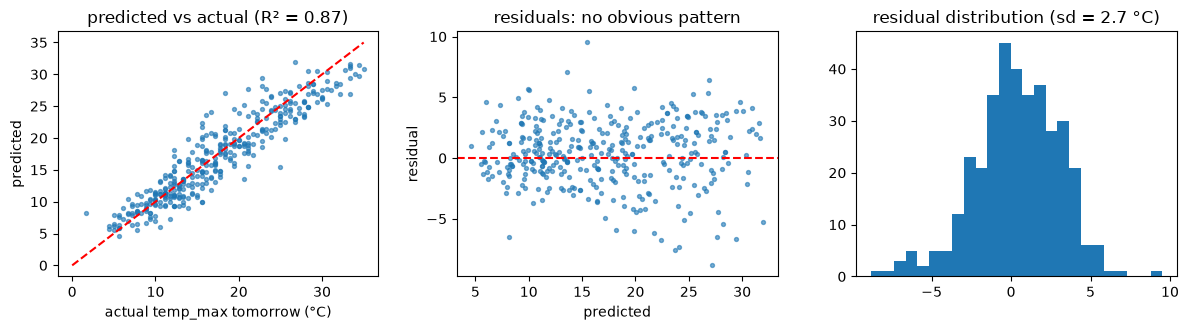

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].scatter(y_te, pred, s=8, alpha=.6); ax[0].plot([0, 35], [0, 35], "r--")
ax[0].set_xlabel("actual temp_max tomorrow (°C)"); ax[0].set_ylabel("predicted"); ax[0].set_title(f"predicted vs actual (R² = {r2(y_te, pred):.2f})")
res = y_te - pred
ax[1].scatter(pred, res, s=8, alpha=.6); ax[1].axhline(0, color="r", ls="--")
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("residual"); ax[1].set_title("residuals: no obvious pattern")
ax[2].hist(res, bins=25); ax[2].set_title(f"residual distribution (sd = {res.std():.1f} °C)")
plt.tight_layout(); plt.show()

### Ridge regression: shrinking the weights
Ridge adds a penalty $\alpha\sum w^2$ that keeps the weights small. We pick $\alpha$ on **2014** (a validation year taken
from the training data), never on the 2015 test year.

In [5]:
fit_part, val_part = train[train.date < "2014-01-01"], train[train.date >= "2014-01-01"]
for alpha in [0.01, 1, 10, 100, 1000]:
    m = Ridge(alpha=alpha).fit(fit_part[FEATURES], fit_part.temp_tomorrow)
    print(f"alpha {alpha:>7}: validation RMSE {rmse(val_part.temp_tomorrow, m.predict(val_part[FEATURES])):.3f}")

alpha    0.01: validation RMSE 2.752
alpha       1: validation RMSE 2.751
alpha      10: validation RMSE 2.744
alpha     100: validation RMSE 2.747
alpha    1000: validation RMSE 2.799


The errors barely change: with 1,000 days and only 6 inputs there is little to shrink. Ridge matters when inputs are many or noisy.

### Bayesian view: how sure is each prediction?
Instead of one set of weights, keep a **distribution** over them. With a Gaussian prior the posterior is also Gaussian,
and every prediction comes with an uncertainty.

In [6]:
alpha, beta = 1.0, 1 / (y_tr - X_tr @ w).var()     # prior precision, noise precision (noise measured on the training data)
Xs = np.c_[np.ones(len(train)), (train[FEATURES] - train[FEATURES].mean()) / train[FEATURES].std()]
Xt = np.c_[np.ones(len(test)),  (test[FEATURES]  - train[FEATURES].mean()) / train[FEATURES].std()]
S = np.linalg.inv(alpha * np.eye(Xs.shape[1]) + beta * Xs.T @ Xs)   # posterior covariance of the weights
m = beta * S @ Xs.T @ y_tr                                          # posterior mean of the weights
mean = Xt @ m
sd = np.sqrt(1 / beta + np.einsum("ij,jk,ik->i", Xt, S, Xt))        # noise + weight uncertainty
inside = np.abs(y_te - mean) < 1.96 * sd
print(f"RMSE {rmse(y_te, mean):.2f} °C | 95% interval covers {inside.mean():.0%} of test days (ideal: 95%)")

RMSE 2.70 °C | 95% interval covers 95% of test days (ideal: 95%)


## Practice 2 — Classification: will it rain tomorrow?
Two baselines: always say "no rain" (the majority class) and "tomorrow = today".

In [7]:
Xc_tr, Xc_te = train[FEATURES].values, test[FEATURES].values
yc_tr, yc_te = train.rain_tomorrow.values, test.rain_tomorrow.values
sc = StandardScaler().fit(Xc_tr)
Z_tr, Z_te = sc.transform(Xc_tr), sc.transform(Xc_te)

acc = lambda y, p: (y == p).mean()
print(f"baseline 'always no rain':     accuracy {acc(yc_te, 0):.3f}")
print(f"baseline 'tomorrow = today':   accuracy {acc(yc_te, test.rain.values):.3f}")

baseline 'always no rain':     accuracy 0.604
baseline 'tomorrow = today':   accuracy 0.703


### Logistic regression
$P(\text{rain}) = \sigma(w^Tx)$ where $\sigma(z)=1/(1+e^{-z})$ squashes any number into a probability.

In [8]:
logit = LogisticRegression(max_iter=1000).fit(Z_tr, yc_tr)
p_logit = logit.predict_proba(Z_te)[:, 1]
print(f"logistic regression:           accuracy {acc(yc_te, p_logit > .5):.3f} | log-loss {log_loss(yc_te, p_logit):.3f}")

logistic regression:           accuracy 0.731 | log-loss 0.558


### Bayesian logistic regression (Laplace approximation)
There is no closed form for the posterior, so we approximate it with a Gaussian centred on the most likely weights
(found with Newton's method), whose width comes from the curvature there.

In [9]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))
A = np.c_[np.ones(len(Z_tr)), Z_tr]; At = np.c_[np.ones(len(Z_te)), Z_te]
prior = 1.0                                         # prior precision: weights are expected to be small
wmap = np.zeros(A.shape[1])
for _ in range(25):                                 # Newton's method for the most likely weights
    p = sigmoid(A @ wmap)
    grad = A.T @ (p - yc_tr) + prior * wmap
    hess = A.T @ (A * (p * (1 - p))[:, None]) + prior * np.eye(len(wmap))
    wmap -= np.linalg.solve(hess, grad)
cov = np.linalg.inv(hess)                           # Gaussian approximation of the posterior

mu = At @ wmap
var = np.einsum("ij,jk,ik->i", At, cov, At)         # uncertainty about each prediction's score
p_bayes = sigmoid(mu / np.sqrt(1 + np.pi * var / 8))  # predictive probability, softened when unsure
print(f"Bayesian logistic regression:  accuracy {acc(yc_te, p_bayes > .5):.3f} | log-loss {log_loss(yc_te, p_bayes):.3f}")

Bayesian logistic regression:  accuracy 0.731 | log-loss 0.558


In [10]:
names = ["intercept"] + FEATURES
print("weight   mean ± sd   (large |mean| / sd = the model is sure this input matters)")
for n, a, b in zip(names, wmap, np.sqrt(np.diag(cov))):
    print(f"{n:>14}: {a:+.2f} ± {b:.2f}")

weight   mean ± sd   (large |mean| / sd = the model is sure this input matters)
     intercept: -0.28 ± 0.07
 precipitation: +0.63 ± 0.11
      temp_max: -1.06 ± 0.18
      temp_min: +1.18 ± 0.16
          wind: -0.04 ± 0.07
     month_sin: +0.54 ± 0.11
     month_cos: +0.54 ± 0.12


Note the opposite signs on `temp_max` and `temp_min`: a **small gap** between the day's high and low (a cloudy day) points to rain.

### Support vector machines
An SVM finds the boundary with the widest margin. The **RBF kernel** lets that boundary curve without adding features by hand.

In [11]:
results = {}
for name, svm in {"linear SVM": SVC(kernel="linear", C=1), "RBF SVM": SVC(kernel="rbf", C=1, gamma="scale")}.items():
    svm.fit(Z_tr, yc_tr); results[name] = acc(yc_te, svm.predict(Z_te))
    print(f"{name:>29}: accuracy {results[name]:.3f} | support vectors {svm.n_support_.sum()} of {len(Z_tr)}")

                   linear SVM: accuracy 0.725 | support vectors 698 of 1096
                      RBF SVM: accuracy 0.720 | support vectors 699 of 1096


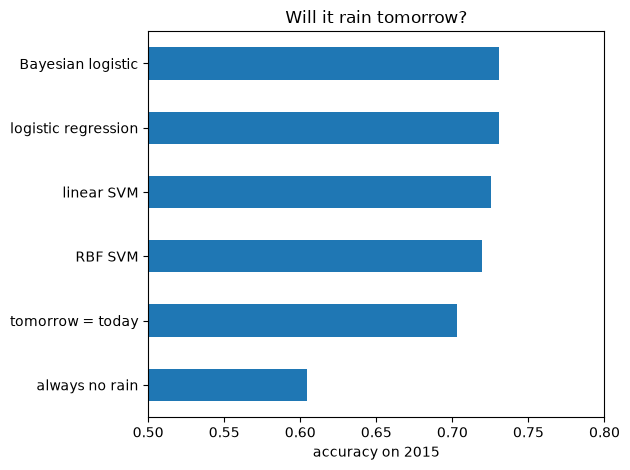

always no rain         0.604
tomorrow = today       0.703
logistic regression    0.731
Bayesian logistic      0.731
linear SVM             0.725
RBF SVM                0.720
dtype: float64

In [12]:
table = pd.Series({
    "always no rain": acc(yc_te, 0), "tomorrow = today": acc(yc_te, test.rain.values),
    "logistic regression": acc(yc_te, p_logit > .5), "Bayesian logistic": acc(yc_te, p_bayes > .5), **results,
})
table.sort_values().plot.barh(color="tab:blue"); plt.xlim(.5, .8); plt.xlabel("accuracy on 2015")
plt.title("Will it rain tomorrow?"); plt.tight_layout(); plt.show()
table.round(3)

## Summary
* Tomorrow's temperature: a plain linear model beats "tomorrow = today" (RMSE 2.7 vs 2.9 °C), and the Bayesian version also says how unsure it is.
* Rain tomorrow is much harder. All the models land close to the "tomorrow = today" baseline, because today's weather
  already holds most of what can be known. The best models gain only about 3 points over that baseline.
* Bayesian logistic regression matches ordinary logistic regression here: with 1,096 days the posterior is narrow.
  Its benefit is the uncertainty on every weight, e.g. `wind` is not clearly useful (its sd is as large as its weight).